<a href="https://colab.research.google.com/github/bhanu151/statistical-learning-course-2026/blob/main/CSSL_10_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

Let's load the Iris dataset

In [3]:
iris = load_iris()
X_raw = pd.DataFrame(iris.data[:, :4], columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
y_raw = iris.target
type(iris)

sklearn.utils._bunch.Bunch

Use the below function for plotting. The data that is passed needs to be a pandas dataframe.

In [4]:
# Plotting function
def scatter_helper(data, x_axis_column_name, y_axis_column_name, encoded_class_labels, title):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=data, x=x_axis_column_name, y=y_axis_column_name, hue=encoded_class_labels, palette='viridis', s=70)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

1. Scale the X_raw using StandardScaler. Convert it into a dataframe since the plotting function expects a dataframe.
2. Encode y values using label encoder

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = pd.DataFrame(X_scaled, columns=X_raw.columns)
y = LabelEncoder().fit_transform(y_raw)

3. Scatter the original scaled data along any two features using the above plotting function. Try this step for different combinations of features and identify which pairs of features show correlations. You can use the scatter_helper I have defined above.

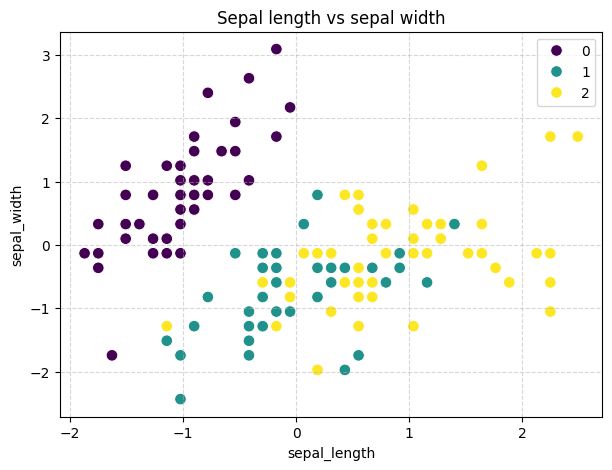

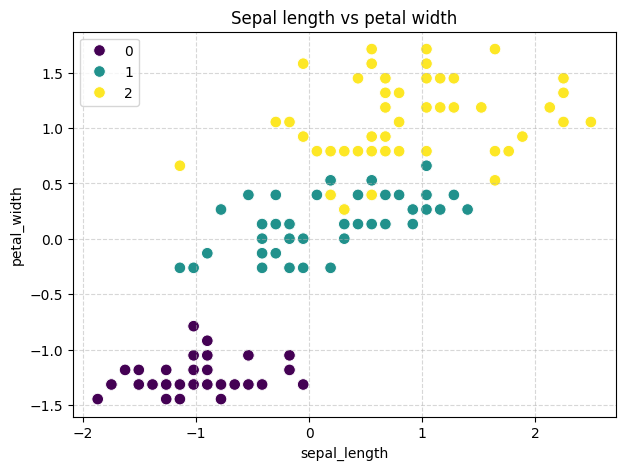

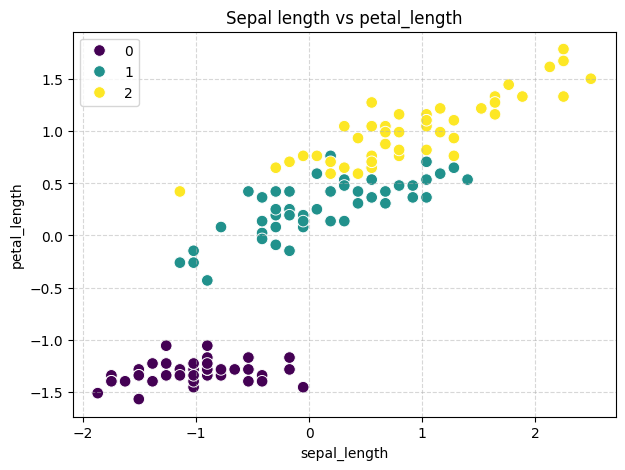

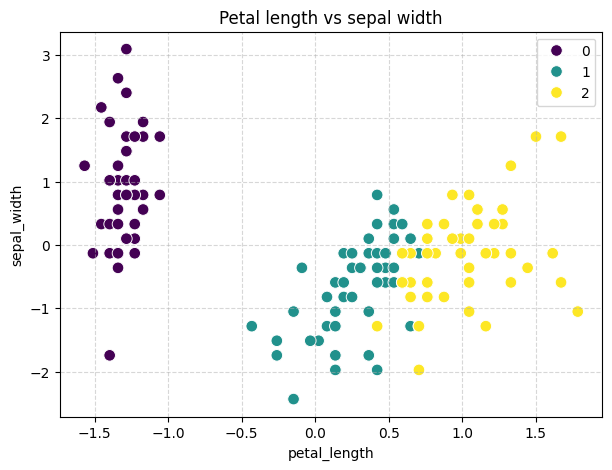

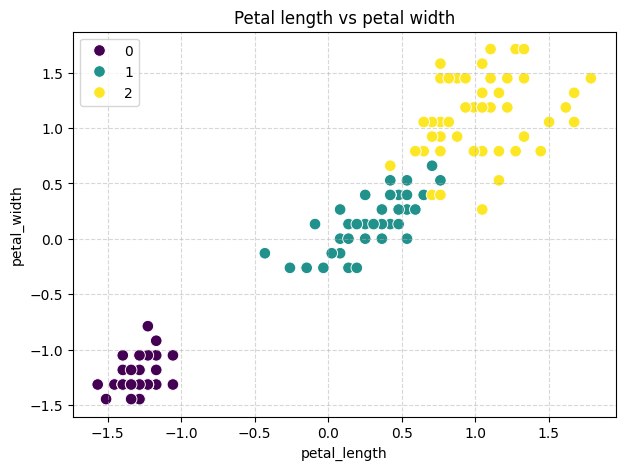

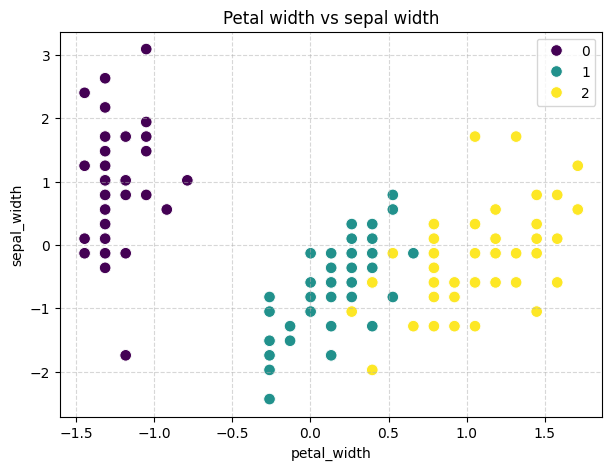

In [61]:
scatter_helper(X, "sepal_length", "sepal_width", y, "Sepal length vs sepal width")
scatter_helper(X, "sepal_length", "petal_width", y, "Sepal length vs petal width")
scatter_helper(X, "sepal_length", "petal_length", y, "Sepal length vs petal_length")
scatter_helper(X, "petal_length", "sepal_width", y, "Petal length vs sepal width")
scatter_helper(X, "petal_length", "petal_width", y, "Petal length vs petal width")
scatter_helper(X, "petal_width", "sepal_width", y, "Petal width vs sepal width")

Glancing at these plots, petal length, petal width and sepal length show some degree of correlation with each other. However sepal width doesn't seem to be correlating with any of these features.

4. Create a PCA model containing as many components as the number of features. Fit-transform the model with the scaled X data.
5. Create a dataframe with the X_pca. Ensure that your give names to different columns, i.e., "PC1", "PC2"...

In [62]:
num_features = X.shape[1] # Number of columns in X
pca_model = PCA(n_components=num_features)
X_pca = pca_model.fit_transform(X)
df_X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3", "PC4"])

5. Scatter the datapoints in the new space with PC1 and PC2 as the new axis. Again, you can take help of the scatter_helper defined above.

***The y values haven't changed because the class labels aren't used in PCA since it is an unsupervised learning method. In fact, we don't need the class labels at all. We are just visualizing for out own convenience. In reality even if the class labels weren't present, you'd still be able to perform PCA on the data using just the X values.***

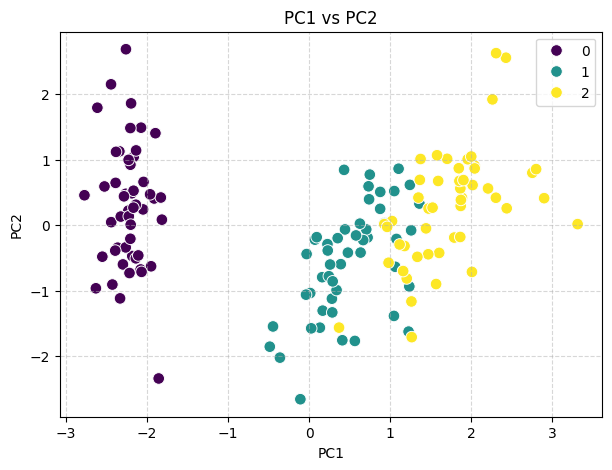

In [63]:
scatter_helper(df_X_pca, "PC1", "PC2", y, "PC1 vs PC2")

6. Plot the scree plot to look at the proportion of variance captured by each PC. In addition, you can plot the cumulative proportion or variance captured by the first n PCs in the same plot using np.cumsum and plt.step

pve = [0.72962445 0.22850762 0.03668922 0.00517871]


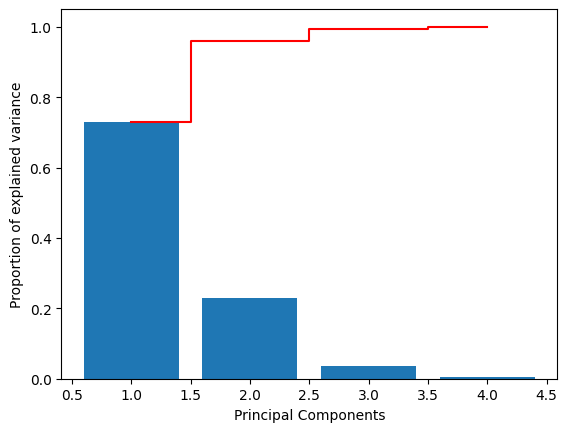

In [66]:
pve = pca_model.explained_variance_ratio_ # Proportion of variance explained by each Principal Component (PC)
cum_sum_pve = np.cumsum(pve) # Cumulative sum of pve
print(f"pve = {pve}")
plt.figure()
plt.bar(np.arange(1, pca_model.n_components_+1), pve, label="pve", align="center")
plt.step(np.arange(1, pca_model.n_components_+1), cum_sum_pve, c="r", where="mid", label="cumulative pve")
plt.xlabel("Principal Components")
plt.ylabel("Proportion of explained variance")
plt.xticks()
plt.show()

Notice how the first two principal components (PC1 and PC2) together are capturing ~95% of the total variance. If we were to ignore PC3 and PC4, we'd only lose ~5% of the total variance.

7. Extract the loadings of the components, tranpose them, and visualize them using a heatmap. The seaborn library can be used for visualization.

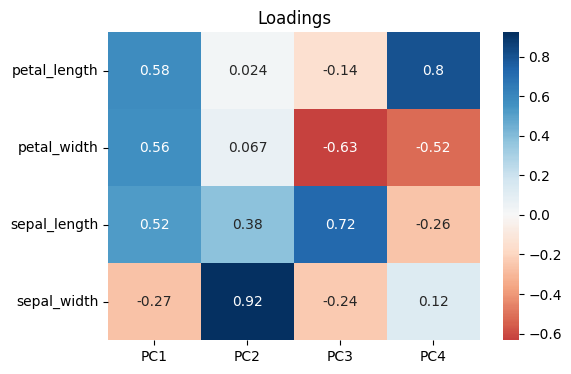

In [80]:
plt.figure(figsize=(6,4))
loadings = pd.DataFrame(
    pca_model.components_.T, # transposed PCA components
    columns=df_X_pca.columns,
    index=X.columns   # use the feature names form the iris dataset
)

sns.heatmap(loadings.sort_values(by="PC1", ascending=False), annot=True, cmap="RdBu", center=0)
plt.title("Loadings")

plt.show()


Note how all the three features which were earlier showing correlations (petal length, petal width and sepal length) are positively contributing to PC1, i.e., show postive loadings. PC2 on the other hand is being strongly dominated by sepal width, and to some extend by sepal length.

8. Reconstruct the scaled X values from the first two principal components. You will need to create a new pca model with n_components=2. You will also need to invert the scaling. Hint: Check inverse_transform function from the PCA model, and inverse transform from standard scaler.

9. Scatter plot pairs of the reconstructed values of the different features (petal length, petal width, sepal length, sepal width). Assess how they compare with the original X raw values.

10. Compare the mean squared error (reconstruction error) between the original X values and the reconstructed X values.

Reconstruction errors considering all features
reconstruction errors for each datapoint
 0      0.003461
1      0.018449
2      0.000579
3      0.004648
4      0.000833
         ...   
145    0.079297
146    0.027587
147    0.009978
148    0.140240
149    0.073241
Length: 150, dtype: float64
Average reconstruction error = 0.0355373068008793


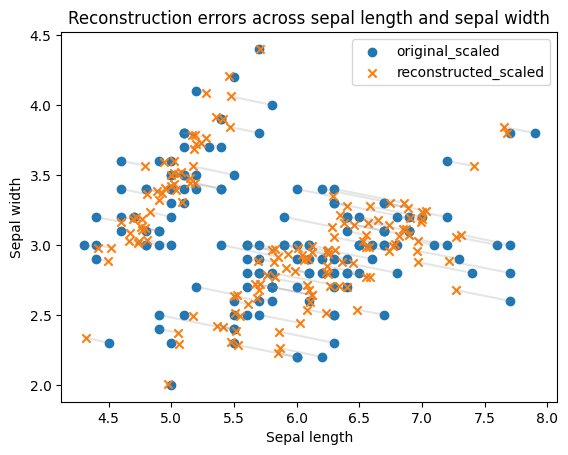

In [79]:
two_component_pca_model = PCA(n_components=2)
X_pca_two_components = two_component_pca_model.fit_transform(X)

X_recon_from_two_comp_scaled = two_component_pca_model.inverse_transform(X_pca_two_components)
X_recon_from_two_comp_unscaled = scaler.inverse_transform(X_recon_from_two_comp_scaled)

plt.figure()
plt.scatter(X_raw["sepal_length"], X_raw["sepal_width"], marker="o", label="original_scaled")
plt.scatter(X_recon_from_two_comp_unscaled[:, 0], X_recon_from_two_comp_unscaled[:, 1], marker="x", label="reconstructed_scaled")

for i in range(X.shape[0]): # for each datapoint in the dataset
  plt.plot([X_raw.iloc[i, 0], X_recon_from_two_comp_unscaled[i, 0]], [X_raw.iloc[i, 1], X_recon_from_two_comp_unscaled[i, 1]], 'gray', alpha=0.2)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.legend()
plt.title("Reconstruction errors across sepal length and sepal width")

print("Reconstruction errors considering all features")
recon_error = np.mean((X_raw - X_recon_from_two_comp_unscaled)**2, axis=1)
print(f"reconstruction errors for each datapoint\n {recon_error}")
print(f"Average reconstruction error = {np.mean(recon_error)}")

The grey lines represent the error that comes in when we reconstruct the features using just the first 2 principal components, since we lose ~5% of the total variance.